# Midterm Take Home

## Shane Waldron

## GSB 545

In [1]:
# Importing libraries
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*"
)


#### Exploratory Data Analysis

In [2]:
# Data loading
df = pd.read_csv('data/midterm_train.csv')
df.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [3]:
df.columns

Index(['id', 'customer_age', 'occupation_type', 'relationship_status',
       'education_background', 'has_credit_issue', 'mortgage_status',
       'personal_loan_status', 'last_contact_month', 'day_of_week',
       'contact_time_minutes', 'contact_attempt_count',
       'days_since_prior_contact', 'prior_contact_count',
       'prior_outcome_status', 'economic_activity_change',
       'consumer_price_index', 'consumer_confidence_index',
       'reference_interest_rate', 'employment_level_index', 'accepted_offer',
       'is_repeat_customer', 'recent_contact_flag'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         32950 non-null  int64  
 1   customer_age               32950 non-null  int64  
 2   occupation_type            32950 non-null  object 
 3   relationship_status        32950 non-null  object 
 4   education_background       32950 non-null  object 
 5   has_credit_issue           32950 non-null  object 
 6   mortgage_status            32950 non-null  object 
 7   personal_loan_status       32950 non-null  object 
 8   last_contact_month         32950 non-null  object 
 9   day_of_week                32950 non-null  object 
 10  contact_time_minutes       32950 non-null  int64  
 11  contact_attempt_count      32950 non-null  int64  
 12  days_since_prior_contact   32950 non-null  int64  
 13  prior_contact_count        32950 non-null  int

In [5]:
# EDA
df.describe()

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,20612.919423,40.016813,257.355387,2.556601,961.748892,0.173445,0.077132,93.574951,-40.508273,3.614729,5166.787681,0.112747,0.136510,0.037511
std,11872.660725,10.421766,256.687433,2.751165,188.697125,0.496422,1.572468,0.579559,4.628221,1.737144,72.459588,0.316288,0.343334,0.190014
min,0.000000,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000
25%,10373.250000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,0.000000
50%,20610.500000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000,0.000000
75%,30858.750000,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000,0.000000
max,41187.000000,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000


In [6]:
# Checking for missing values
df.isnull().sum()

id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
accepted_offer               0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64

In [7]:
import sweetviz as sv
report = sv.analyze(df)
report.show_html('sweetviz_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Scanning over the sweetviz report, there are quite a few unknown values in various columns, but I dont think removing them or imputation is necessary for any of the values.

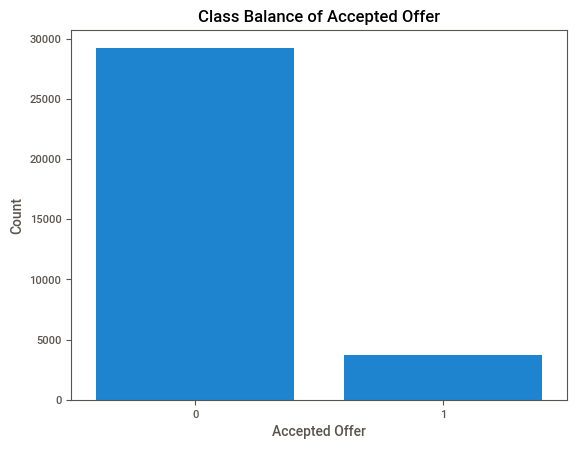

In [8]:
# Checking class balance of accepted_offer
sns.countplot(x='accepted_offer', data=df)
plt.title('Class Balance of Accepted Offer')
plt.xlabel('Accepted Offer')
plt.ylabel('Count')
plt.show()

We have a lot of class imbalance, so we'll need to account for that when we get to the modeling steps.

In [9]:
# Numerical features (require scaling)
numerical_features = [
    'customer_age', 
    'contact_time_minutes', 
    'contact_attempt_count', 
    'days_since_prior_contact', 
    'prior_contact_count', 
    'economic_activity_change', 
    'consumer_price_index', 
    'consumer_confidence_index', 
    'reference_interest_rate', 
    'employment_level_index'
]

# Categorical features (require encoding)
categorical_features = [
    'occupation_type', 
    'relationship_status', 
    'education_background', 
    'has_credit_issue', 
    'mortgage_status', 
    'personal_loan_status', 
    'last_contact_month', 
    'day_of_week', 
    'prior_outcome_status'
]

# Binary features 
binary_features = [
    'is_repeat_customer', 
    'recent_contact_flag'
]

# Target variable
target = 'accepted_offer'

# ID column (to be dropped or set as index)
unused_columns = ['id']

In [10]:
# Data preprocessing
plot_df = df.copy()

plot_df['no_prior_contact'] = (
    plot_df['days_since_prior_contact'] == 999
).astype(int)

plot_df['days_since_prior_contact_clean'] = (
    plot_df['days_since_prior_contact'].replace(999, np.nan)
)


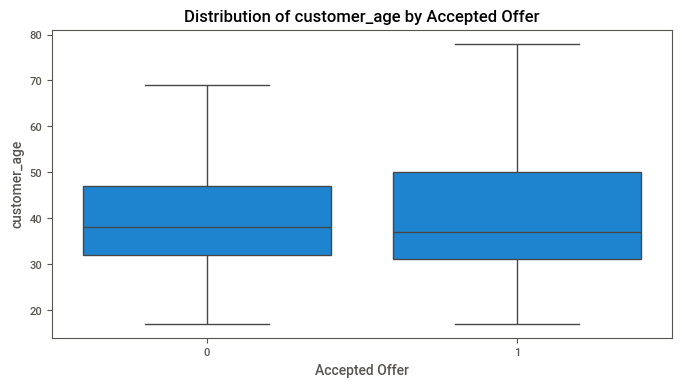

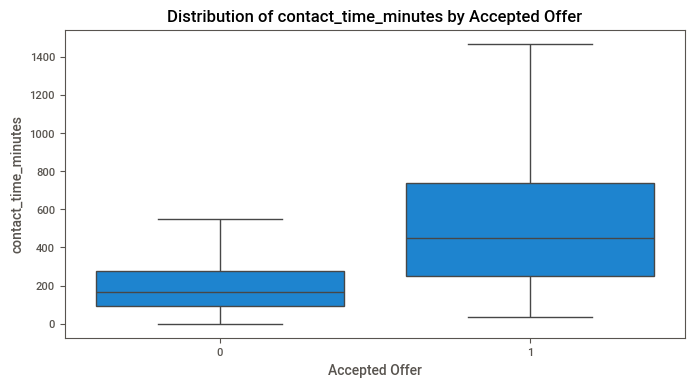

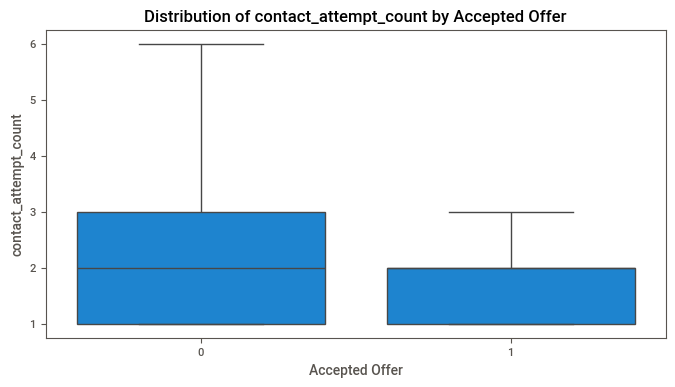

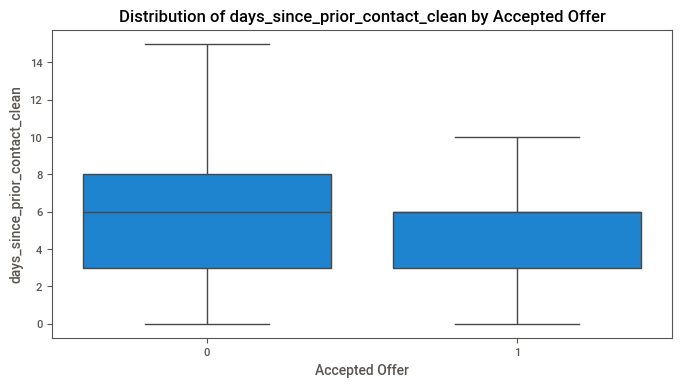

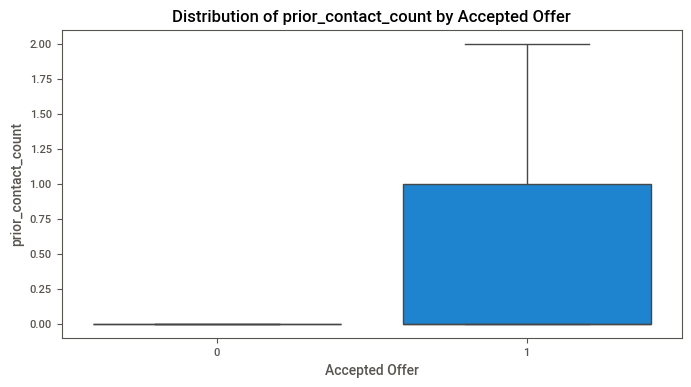

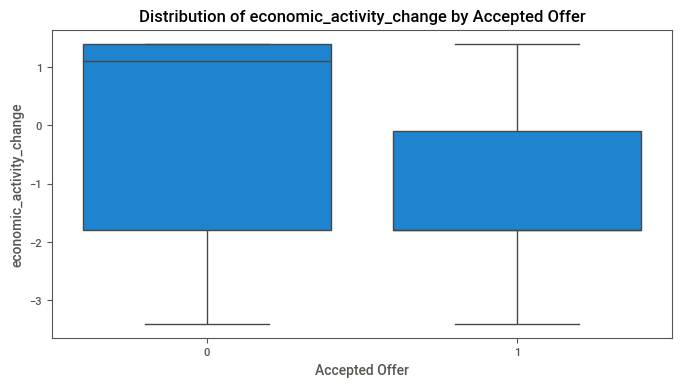

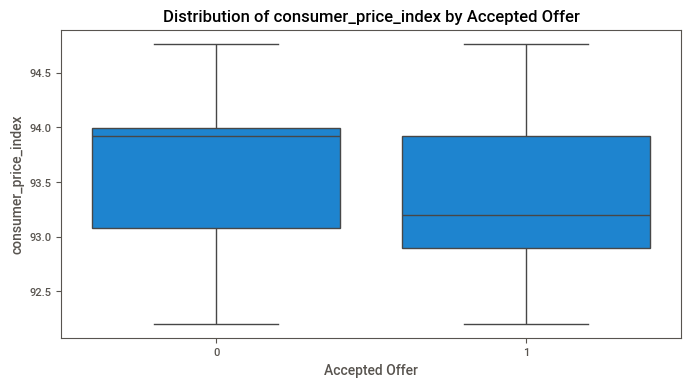

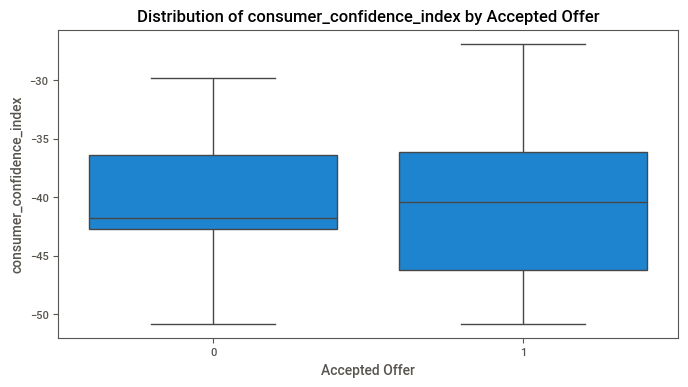

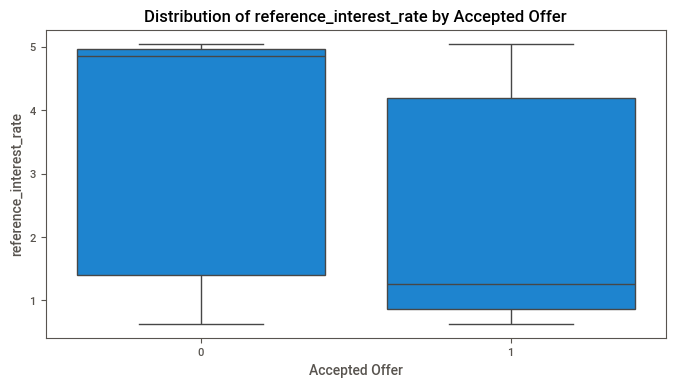

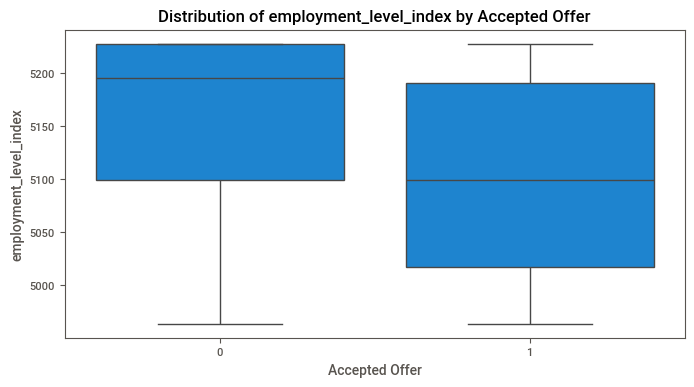

In [11]:
boxplot_features = [
    'customer_age', 
    'contact_time_minutes', 
    'contact_attempt_count', 
    'days_since_prior_contact_clean', 
    'prior_contact_count', 
    'economic_activity_change', 
    'consumer_price_index', 
    'consumer_confidence_index', 
    'reference_interest_rate', 
    'employment_level_index'
]

for col in boxplot_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=plot_df, x='accepted_offer', y=col, showfliers=False)
    plt.title(f'Distribution of {col} by Accepted Offer')
    plt.xlabel('Accepted Offer')
    plt.ylabel(col)
    plt.show()


The numerical boxplots show several skewed variables with wide spreads. contact_time_minutes has the clearest separation: accepted customers generally had much longer contact durations than non-accepted customers. contact_attempt_count is concentrated at low values, but non-accepted customers show a wider range of attempts. prior_contact_count is mostly zero, though accepted customers show slightly more prior contact history.

For days_since_prior_contact, the 999 value was handled separately as a missing/no-prior-contact code, so the cleaned plot only shows actual prior-contact timing. Among those customers, both groups are centered around roughly 6 days. The economic variables also show differences: accepted customers tend to be associated with lower economic_activity_change, lower reference_interest_rate, and lower employment_level_index. customer_age looks fairly similar across groups.

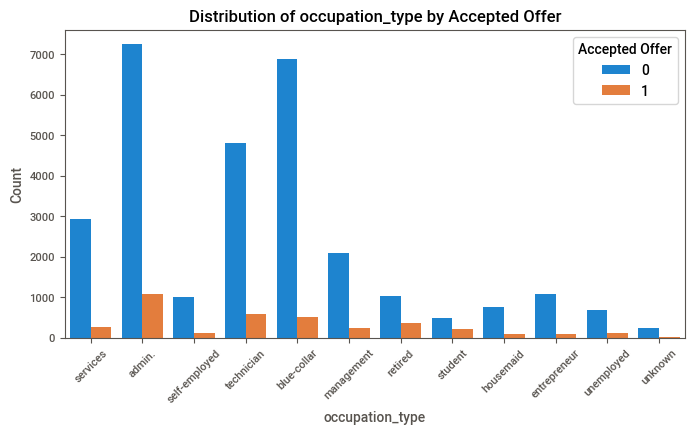

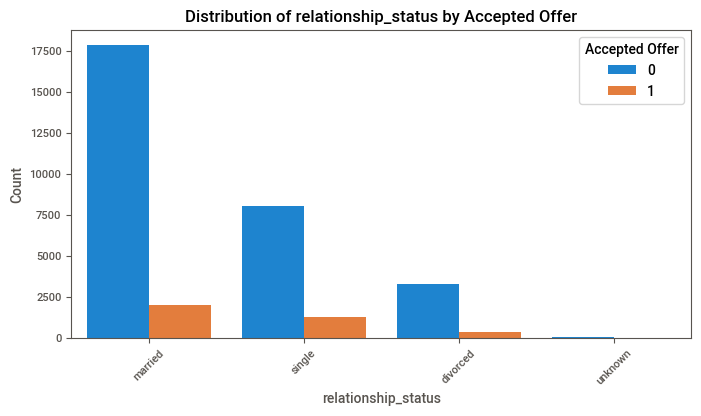

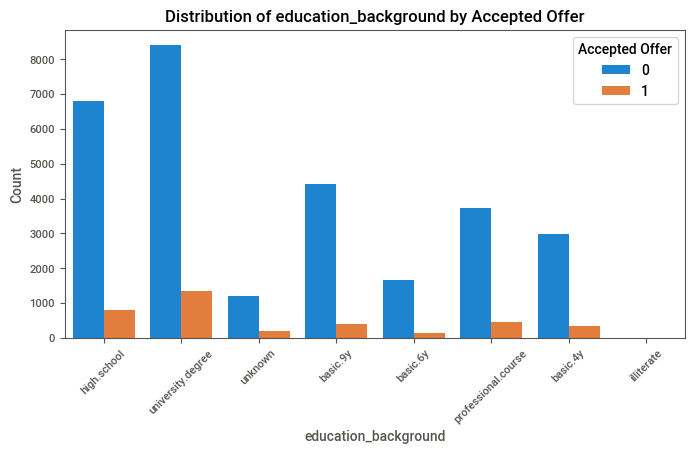

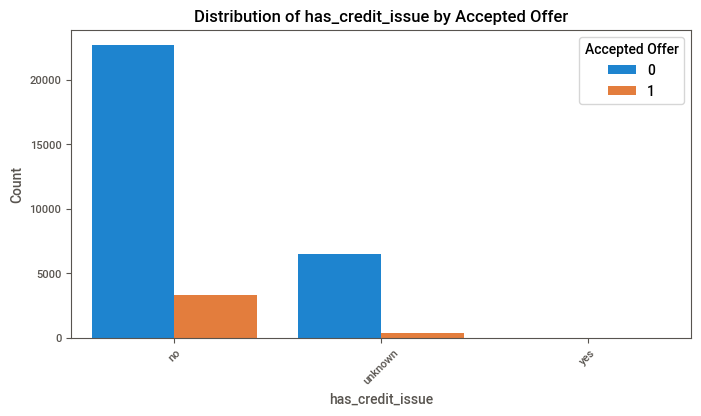

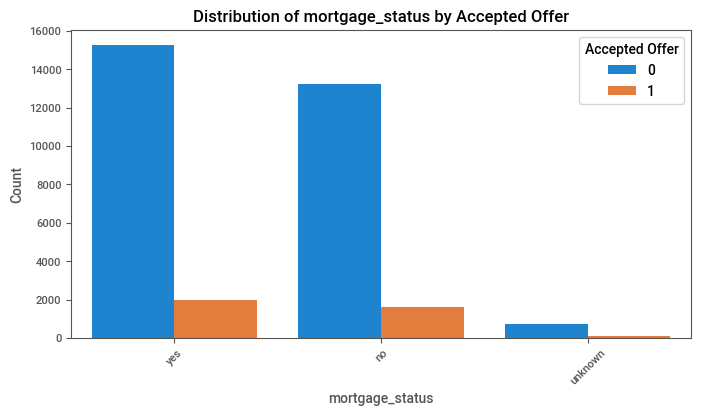

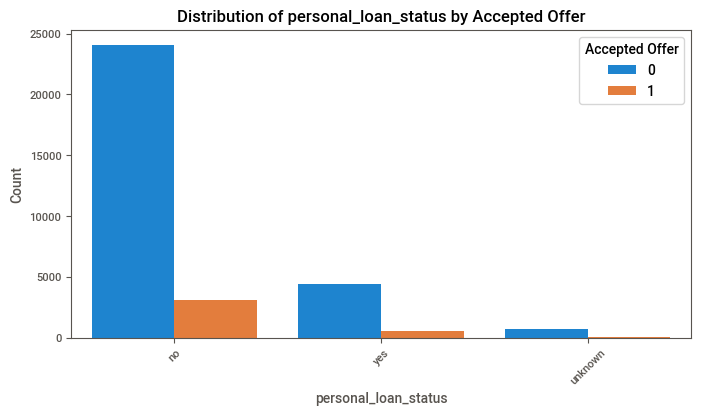

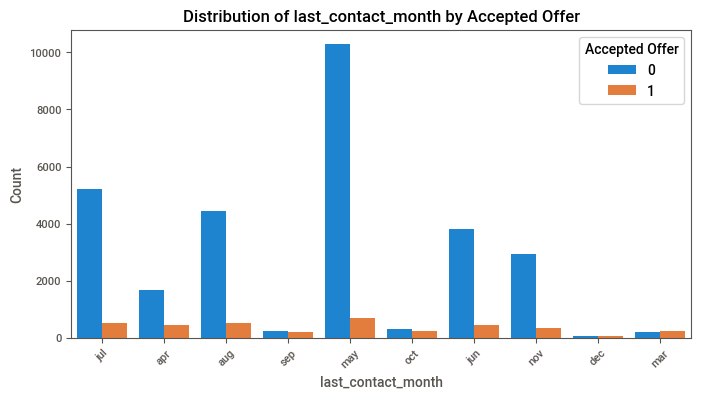

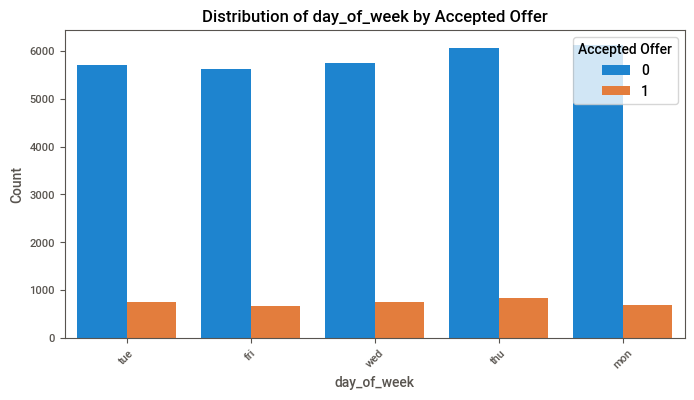

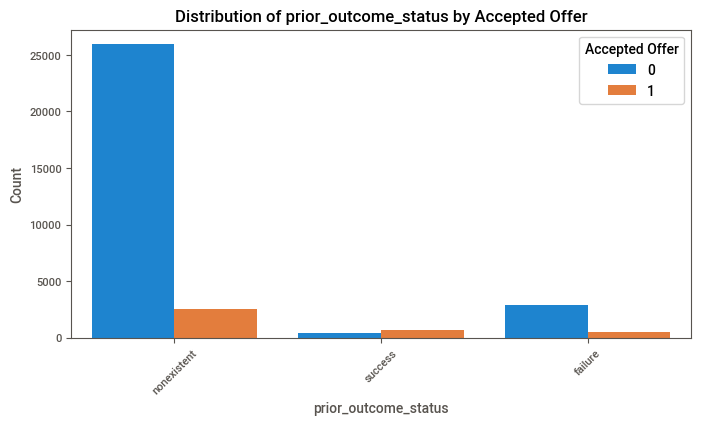

In [12]:
# Categorical features distribution
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=plot_df, x=col, hue='accepted_offer')
    plt.title(f'Distribution of {col} by Accepted Offer')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Accepted Offer', loc='upper right')
    plt.xticks(rotation=45)
    plt.show()

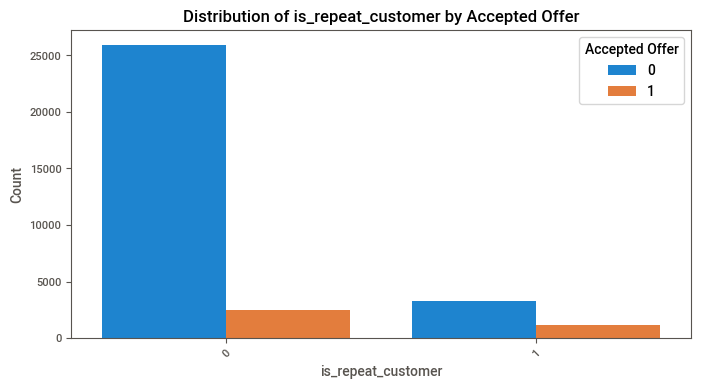

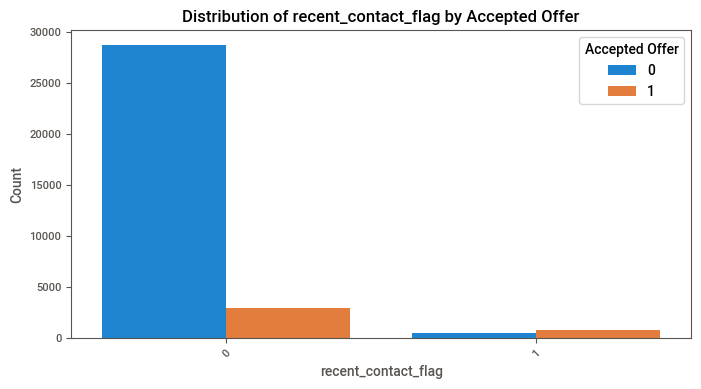

In [13]:
# Binary features distribution
for col in binary_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=plot_df, x=col, hue='accepted_offer')
    plt.title(f'Distribution of {col} by Accepted Offer')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Accepted Offer', loc='upper right')
    plt.xticks(rotation=45)
    plt.show()

The categorical plots show that most categories are dominated by non-accepted offers because of the class imbalance. The largest occupation groups are admin., blue-collar, and technician, while student and retired customers appear to have stronger acceptance proportions. Most customers are married, but single customers show a slightly higher share of accepted offers. For education, university.degree and high.school are the largest groups, with university-educated customers showing somewhat stronger acceptance.

Timing and prior-contact variables show the clearest categorical differences. may has the largest number of contacts but mostly non-accepted offers, while smaller months such as mar, sep, oct, and dec show stronger acceptance proportions. day_of_week appears fairly balanced and does not show a major difference. The strongest signals are in prior_outcome_status, is_repeat_customer, and recent_contact_flag: customers with a prior successful outcome, repeat customers, and recently contacted customers are much more likely to accept the offer.

### Data Preparation

In [14]:
# Data preparation

train_df = pd.read_csv("data/midterm_train.csv")
test_df = pd.read_csv("data/midterm_test.csv")

y = train_df[target]
X = train_df.drop(columns=[target] + unused_columns)

In [15]:
# Create a flag for customers with no prior contact
X["no_prior_contact"] = (X["days_since_prior_contact"] == 999).astype(int)
test_df["no_prior_contact"] = (test_df["days_since_prior_contact"] == 999).astype(int)

# Replace 999 with 0 for the numeric version
# The flag preserves the meaning of "no prior contact"
X["days_since_prior_contact"] = X["days_since_prior_contact"].replace(999, 0)
test_df["days_since_prior_contact"] = test_df["days_since_prior_contact"].replace(999, 0)


The data preparation step reloads the original training and test datasets to ensure that no EDA filtering affects modeling. The target variable, accepted_offer, is separated from the predictors, and the id column is removed from the feature set because it is only an identifier. The special value 999 in days_since_prior_contact is treated as “no prior contact” rather than as a true numeric value. To preserve this information, a binary no_prior_contact feature is created, and the original value is replaced for modeling. Categorical variables are one-hot encoded, while numerical variables are scaled so that models such as logistic regression can use them appropriately. A stratified train-validation split is used because the target variable is imbalanced.

### Feature Engineering

In [16]:
# Feature Engineering

train_fe = train_df.copy()
test_fe = pd.read_csv("data/midterm_test.csv")

# Prior contact flag from the 999 code
train_fe["no_prior_contact"] = (train_fe["days_since_prior_contact"] == 999).astype(int)
test_fe["no_prior_contact"] = (test_fe["days_since_prior_contact"] == 999).astype(int)

# Replace 999 after creating the flag
train_fe["days_since_prior_contact"] = train_fe["days_since_prior_contact"].replace(999, 0)
test_fe["days_since_prior_contact"] = test_fe["days_since_prior_contact"].replace(999, 0)

# Skewed contact variables
train_fe["log_contact_time_minutes"] = np.log1p(train_fe["contact_time_minutes"])
test_fe["log_contact_time_minutes"] = np.log1p(test_fe["contact_time_minutes"])

train_fe["log_contact_attempt_count"] = np.log1p(train_fe["contact_attempt_count"])
test_fe["log_contact_attempt_count"] = np.log1p(test_fe["contact_attempt_count"])


In [17]:
# Feature list used by the modeling preprocessor
engineered_numeric_features = [
    "customer_age",
    "log_contact_time_minutes",
    "log_contact_attempt_count",
    "days_since_prior_contact",
    "prior_contact_count",
    "economic_activity_change",
    "consumer_price_index",
    "consumer_confidence_index",
    "reference_interest_rate",
    "employment_level_index",
    "is_repeat_customer",
    "recent_contact_flag",
    "no_prior_contact"
]

categorical_features = [
    "occupation_type",
    "relationship_status",
    "education_background",
    "has_credit_issue",
    "mortgage_status",
    "personal_loan_status",
    "last_contact_month",
    "day_of_week",
    "prior_outcome_status"
]


In [18]:
X_engineered = train_fe.drop(columns=[target] + unused_columns)
test_X_engineered = test_fe.drop(columns=unused_columns)

The feature engineering step focuses on variables that showed skewness or special coding during EDA. The `days_since_prior_contact` variable uses 999 to represent no prior contact, so a separate `no_prior_contact` flag was created before replacing the value for modeling. Because `contact_time_minutes` and `contact_attempt_count` are right-skewed, log-transformed versions were created and used in the modeling pipeline. This keeps the meaning of the special 999 value while reducing the influence of extreme contact-duration and campaign-attempt values.


### Modeling and Evaluation

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
    
engineered_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), engineered_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Use engineered data/preprocessor for modeling below
X = X_engineered
test_X = test_X_engineered
preprocessor = engineered_preprocessor


In [21]:
from sklearn.pipeline import Pipeline


In [22]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs"]
}

log_reg_grid = GridSearchCV(
    log_reg_pipeline,
    log_reg_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)
print("Best Logistic Regression Parameters:", log_reg_grid.best_params_)
print("Best Logistic Regression CV AUC:", log_reg_grid.best_score_)

Best Logistic Regression Parameters: {'model__C': 1, 'model__solver': 'lbfgs'}
Best Logistic Regression CV AUC: 0.9375364325306876


Logistic regression was used as an interpretable baseline model. It is a good starting point because it performs well on binary classification problems, works efficiently with one-hot encoded categorical variables, and gives a clear benchmark before moving to more flexible tree-based models. Since the target variable is imbalanced, class weighting was used to help the model pay more attention to the accepted-offer class.

The best logistic regression model used `C = 1` with the `lbfgs` solver and achieved a cross-validated ROC-AUC of about `0.938`. This shows strong ranking ability for a simple linear model, but it also leaves room for tree-based models to capture nonlinear relationships and feature interactions.


In [23]:
# Random Forest with Randomized Search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_search.best_params_)
print("Best Random Forest CV AUC:", rf_search.best_score_)



Best Random Forest Parameters: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best Random Forest CV AUC: 0.946179835495873


The Random Forest model improved on the logistic regression baseline. Logistic regression achieved a cross-validated ROC-AUC of about `0.938`, while the tuned Random Forest achieved a higher ROC-AUC of about `0.946`. This suggests that the Random Forest is capturing nonlinear relationships and feature interactions that the linear logistic regression model cannot fully represent.

The best Random Forest used 600 trees, `sqrt` max features, no maximum depth limit, and `min_samples_leaf = 5`. This setup allows the model to learn flexible patterns while still applying some regularization through the minimum leaf size. The improvement over logistic regression is meaningful, but not huge, which suggests that the linear signal in the data is already strong.


In [24]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_params = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda": [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=25,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_search.best_params_)
print("Best XGBoost CV AUC:", xgb_search.best_score_)


Best XGBoost Parameters: {'model__subsample': 0.8, 'model__reg_lambda': 10, 'model__n_estimators': 600, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best XGBoost CV AUC: 0.9491747346906457


In [25]:
# Creating a classification report for all 3 models

from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

model_dict = {
    "Logistic Regression": log_reg_grid.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

report_rows = []

for model_name, model in model_dict.items():
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    report = classification_report(
        y_val,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    for label, metrics in report.items():
        if isinstance(metrics, dict):
            report_rows.append({
                "model": model_name,
                "class": label,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1_score": metrics["f1-score"],
                "support": metrics["support"],
                "roc_auc": roc_auc_score(y_val, y_proba),
                "pr_auc": average_precision_score(y_val, y_proba)
            })

classification_report_df = pd.DataFrame(report_rows)

classification_report_df


,model,class,precision,recall,f1_score,support,roc_auc,pr_auc
0,Logistic Regression,0,0.985896,0.848811,0.912232,5847.0,0.936981,0.589136
1,Logistic Regression,1,0.431877,0.904441,0.584602,743.0,0.936981,0.589136
2,Logistic Regression,macro avg,0.708886,0.876626,0.748417,6590.0,0.936981,0.589136
3,Logistic Regression,weighted avg,0.923432,0.855083,0.875293,6590.0,0.936981,0.589136
4,Random Forest,0,0.981832,0.887293,0.932171,5847.0,0.944416,0.637976
5,Random Forest,1,0.495406,0.870794,0.631528,743.0,0.944416,0.637976
6,Random Forest,macro avg,0.738619,0.879043,0.781849,6590.0,0.944416,0.637976
7,Random Forest,weighted avg,0.926989,0.885432,0.898275,6590.0,0.944416,0.637976
8,XGBoost,0,0.990066,0.852232,0.915993,5847.0,0.947161,0.648941
9,XGBoost,1,0.445087,0.932705,0.602609,743.0,0.947161,0.648941


The classification report shows a clear precision-recall tradeoff for the accepted-offer class.

Logistic Regression has strong recall, so it identifies many accepted offers, but its lower precision means it produces more false positives. Random Forest improves the default-threshold balance by raising precision and F1 for class 1. XGBoost has the strongest ranking performance, with the highest ROC-AUC and PR-AUC, and it also has the highest class 1 recall.

Overall, Random Forest is strongest at the default threshold, while XGBoost is the best candidate for threshold tuning because its probability ranking is the strongest. The next step is to tune thresholds for Random Forest and XGBoost instead of doing much broader model training.


In [26]:
# Threshold tuning
from sklearn.metrics import precision_score, recall_score, f1_score

def threshold_tuning(model, X_val, y_val, model_name):
    y_proba = model.predict_proba(X_val)[:, 1]
    results = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        y_pred = (y_proba >= threshold).astype(int)

        results.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_val, y_pred),
            "recall": recall_score(y_val, y_pred),
            "f1_score": f1_score(y_val, y_pred)
        })

    return pd.DataFrame(results)
rf_thresholds = threshold_tuning(
    rf_search.best_estimator_,
    X_val,
    y_val,
    "Random Forest"
)

xgb_thresholds = threshold_tuning(
    xgb_search.best_estimator_,
    X_val,
    y_val,
    "XGBoost"
)

threshold_results = pd.concat(
    [rf_thresholds, xgb_thresholds],
    ignore_index=True
)

best_thresholds = threshold_results.loc[
    threshold_results.groupby("model")["f1_score"].idxmax()
]

best_thresholds



,model,threshold,precision,recall,f1_score
51,Random Forest,0.56,0.519831,0.829071,0.639004
161,XGBoost,0.75,0.542672,0.787349,0.642504


Threshold tuning improved the usefulness of the models by adjusting how predicted probabilities are converted into class labels. For Random Forest, the best threshold was about `0.56`, giving a class 1 F1-score of about `0.639`. For XGBoost, the best threshold was about `0.75`, producing a slightly higher class 1 F1-score of about `0.643`.

XGBoost remains the strongest individual model after threshold tuning, but the gap between XGBoost and Random Forest is small. Since the models make decisions differently, the next step is to test whether ensembling can improve the final precision-recall balance.


### Ensembling

In [27]:
# Get validation probabilities
log_proba = log_reg_grid.best_estimator_.predict_proba(X_val)[:, 1]
rf_proba = rf_search.best_estimator_.predict_proba(X_val)[:, 1]
xgb_proba = xgb_search.best_estimator_.predict_proba(X_val)[:, 1]

# Simple average ensemble
ensemble_proba = (log_proba + rf_proba + xgb_proba) / 3


In [28]:
ensemble_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    y_pred = (ensemble_proba >= threshold).astype(int)

    ensemble_results.append({
        "model": "Average Ensemble",
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "f1_score": f1_score(y_val, y_pred),
        "roc_auc": roc_auc_score(y_val, ensemble_proba),
        "pr_auc": average_precision_score(y_val, ensemble_proba)
    })

ensemble_results_df = pd.DataFrame(ensemble_results)

ensemble_results_df.loc[
    ensemble_results_df["f1_score"].idxmax()
]


model        Average Ensemble
threshold                0.69
precision            0.552211
recall                0.79004
f1_score             0.650055
roc_auc              0.946308
pr_auc               0.640721
Name: 64, dtype: object

In [29]:
weighted_ensemble_proba = (
    0.2 * log_proba +
    0.3 * rf_proba +
    0.5 * xgb_proba
)
weighted_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    y_pred = (weighted_ensemble_proba >= threshold).astype(int)

    weighted_results.append({
        "model": "Weighted Ensemble",
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "f1_score": f1_score(y_val, y_pred),
        "roc_auc": roc_auc_score(y_val, weighted_ensemble_proba),
        "pr_auc": average_precision_score(y_val, weighted_ensemble_proba)
    })

weighted_results_df = pd.DataFrame(weighted_results)

weighted_results_df.loc[
    weighted_results_df["f1_score"].idxmax()
]


model        Weighted Ensemble
threshold                 0.69
precision             0.547619
recall                0.804845
f1_score              0.651771
roc_auc               0.946883
pr_auc                0.643719
Name: 64, dtype: object

The ensemble results are a small but useful improvement over the best individual model.

Before ensembling, the best threshold-tuned individual model was XGBoost, with a class 1 F1-score of about `0.643`. The simple average ensemble improved F1 to about `0.650`. The best result came from the weighted ensemble using Logistic Regression, Random Forest, and XGBoost probabilities. At a threshold of about `0.69`, it achieved the highest validation F1-score at about `0.652`.

The improvement is modest, and XGBoost still has the strongest individual PR-AUC. However, the weighted ensemble provides the best classification decision at the selected threshold, so it is the final model used for predictions.


### Results Summary

In [30]:
class_1_metrics = classification_report_df[
    classification_report_df["class"] == "1"
].set_index("model")

best_thresholds_by_model = best_thresholds.set_index("model")
average_best = ensemble_results_df.loc[ensemble_results_df["f1_score"].idxmax()]
weighted_best = weighted_results_df.loc[weighted_results_df["f1_score"].idxmax()]

results_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "CV ROC-AUC": log_reg_grid.best_score_,
        "Validation PR-AUC": class_1_metrics.loc["Logistic Regression", "pr_auc"],
        "Best Threshold": 0.50,
        "Validation Precision": class_1_metrics.loc["Logistic Regression", "precision"],
        "Validation Recall": class_1_metrics.loc["Logistic Regression", "recall"],
        "Validation F1": class_1_metrics.loc["Logistic Regression", "f1_score"]
    },
    {
        "Model": "Random Forest",
        "CV ROC-AUC": rf_search.best_score_,
        "Validation PR-AUC": class_1_metrics.loc["Random Forest", "pr_auc"],
        "Best Threshold": best_thresholds_by_model.loc["Random Forest", "threshold"],
        "Validation Precision": best_thresholds_by_model.loc["Random Forest", "precision"],
        "Validation Recall": best_thresholds_by_model.loc["Random Forest", "recall"],
        "Validation F1": best_thresholds_by_model.loc["Random Forest", "f1_score"]
    },
    {
        "Model": "XGBoost",
        "CV ROC-AUC": xgb_search.best_score_,
        "Validation PR-AUC": class_1_metrics.loc["XGBoost", "pr_auc"],
        "Best Threshold": best_thresholds_by_model.loc["XGBoost", "threshold"],
        "Validation Precision": best_thresholds_by_model.loc["XGBoost", "precision"],
        "Validation Recall": best_thresholds_by_model.loc["XGBoost", "recall"],
        "Validation F1": best_thresholds_by_model.loc["XGBoost", "f1_score"]
    },
    {
        "Model": "Average Ensemble",
        "CV ROC-AUC": np.nan,
        "Validation PR-AUC": average_best["pr_auc"],
        "Best Threshold": average_best["threshold"],
        "Validation Precision": average_best["precision"],
        "Validation Recall": average_best["recall"],
        "Validation F1": average_best["f1_score"]
    },
    {
        "Model": "Weighted Ensemble",
        "CV ROC-AUC": np.nan,
        "Validation PR-AUC": weighted_best["pr_auc"],
        "Best Threshold": weighted_best["threshold"],
        "Validation Precision": weighted_best["precision"],
        "Validation Recall": weighted_best["recall"],
        "Validation F1": weighted_best["f1_score"]
    }
])

results_summary = results_summary.round(3)
results_summary


,Model,CV ROC-AUC,Validation PR-AUC,Best Threshold,Validation Precision,Validation Recall,Validation F1
0,Logistic Regression,0.938,0.589,0.50,0.432,0.904,0.585
1,Random Forest,0.946,0.638,0.56,0.520,0.829,0.639
2,XGBoost,0.949,0.649,0.75,0.543,0.787,0.643
3,Average Ensemble,NaN,0.641,0.69,0.552,0.790,0.650
4,Weighted Ensemble,NaN,0.644,0.69,0.548,0.805,0.652


All models used the same preprocessing pipeline: engineered numerical features were scaled, categorical features were one-hot encoded, and `no_prior_contact` was used to preserve the meaning of the 999 value in `days_since_prior_contact`. The individual models were tuned with stratified cross-validation using ROC-AUC, and the final classification threshold was selected on the validation set using F1-score for the accepted-offer class.

The table above contains the main validation metrics. Logistic Regression served as the interpretable baseline, while Random Forest and XGBoost tested whether nonlinear models could improve performance. XGBoost had the strongest individual ranking metrics, but the weighted ensemble achieved the best validation F1-score after threshold tuning.

The weighted ensemble was selected as the final model because it gave the best balance between precision and recall for accepted offers. The final ensemble combines Logistic Regression, Random Forest, and XGBoost probabilities, with the most weight placed on XGBoost because it was the strongest individual model.


### Final Model and Predictions

In [31]:
# Final Model and Predictions

# Refit best models on the full training data
final_log_model = log_reg_grid.best_estimator_
final_rf_model = rf_search.best_estimator_
final_xgb_model = xgb_search.best_estimator_

final_log_model.fit(X, y)
final_rf_model.fit(X, y)
final_xgb_model.fit(X, y);


In [32]:
test_X = test_X_engineered.copy()


In [33]:
test_log_proba = final_log_model.predict_proba(test_X)[:, 1]
test_rf_proba = final_rf_model.predict_proba(test_X)[:, 1]
test_xgb_proba = final_xgb_model.predict_proba(test_X)[:, 1]

test_ensemble_proba = (
    0.2 * test_log_proba +
    0.3 * test_rf_proba +
    0.5 * test_xgb_proba
)

final_threshold = weighted_results_df.loc[
    weighted_results_df["f1_score"].idxmax(),
    "threshold"
]

test_predictions = (test_ensemble_proba >= final_threshold).astype(int)

submission = pd.DataFrame({
    "id": test_fe["id"],
    "accepted_offer": test_predictions
})

submission.to_csv("final_predictions.csv", index=False)
submission.head()


,id,accepted_offer
0,32884,0
1,3169,0
2,32206,1
3,9403,0
4,14020,0
